# Решение уравнений вида $y''=f(x,y,y')$ численным методом для n=32

In [5]:
import matplotlib.pyplot as plt
from problems.boundary_conditions import BoundaryCondition
from problems.nonlin_gen import ODENewton
import numpy as np

---

Ноутбук посвящен численному решению нелинейного уравнения вида $$y'' = \sqrt{\frac{1 - (y')^2}{y}}$$
с помощью комбинации метода Ньютона и обычного солвера для уравнения вида $y''+p(x)y'+q(x)y=f(x)$

Сам класс принимает на вход функцию и гранич. усл. A = ODENewton(def  F, bc  Boundary_conditions)



Имеет методы: A.solve(n) -> bool, решает уравнение, и сохраняет внутри(!) себя вектор решения y, отдает получилось ли решить

A.get_solution() -> np.ndarray, отдает вектор решения, те Y = A.get_solution()

еще сохраняет массив ошибок err, кол-во итераций на сходимость iter_needed, сетку x_grid


Не придумал как разнести солвер и генератор, тк в отличие от обычного получения матриц A и b в генераторе, которые потом можно решить в разных солверах, здесь матрицы пересоздаются и решаются в каждой итерации метода .solve, и что делать станд-алон генератору не ясно(((


ВАЖНО: функцию в класс надо заводить именно так, от трех переменных x, y, dy

In [9]:
def myfunc(x, y, dy):
    return (-1 - dy * dy) / y


n = 32   # колво точек
y0 = 1   # значение в x=0
y1 = 1   # значение в x=1
bc = BoundaryCondition(-1, -1, y0, y1)
taktak = ODENewton(myfunc, bc)
taktak.solve(n)

True

В блоке выше задали кол-во точек в центрированной сетке $n$ (значение бертся с центра ячейки) и решили уравнение. По сути уже все, внутри обьекта taktak хранится вектор-решение $y$ который можно получить через .get_solution (это и будет сделано ниже)

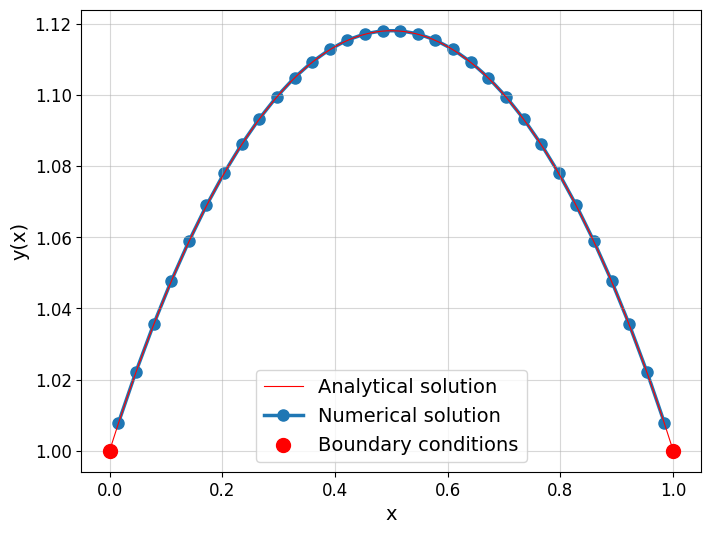

[1.00781057 1.02223874 1.03552376 1.04770909 1.05883269 1.06892769
 1.07802296 1.08614362 1.09331137 1.09954484 1.10485983 1.10926955
 1.11278474 1.11541387 1.11716319 1.11803682 1.11803682 1.11716319
 1.11541387 1.11278474 1.10926955 1.10485983 1.09954484 1.09331137
 1.08614362 1.07802296 1.06892769 1.05883269 1.04770909 1.03552376
 1.02223874 1.00781057]


In [10]:
y_1 = taktak.get_solution()
x_1 = taktak.x_grid
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
nd = np.linspace(0, 1, n, endpoint=True)
nd_fine = np.linspace(0, 1, 200, endpoint=True)
rel_sol = np.sqrt(1+nd_fine*(1-nd_fine))
plt.plot(nd_fine, rel_sol, color='red', lw=0.8, ms=0, label="Analytical solution", zorder=3)
plt.plot(x_1, y_1, '-o', lw=2.5, ms=8, label="Numerical solution", zorder=1)
plt.scatter((0, 1), (y0, y1), color='red', s=100, label="Boundary conditions", zorder=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('y(x)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
plt.show()
print(y_1)
plt.show()


Построим график решения, синим точки моего решения, а красным - аналитического + гр. условия - благо все это знаем

Теперь построим график зависимости ошибки от номера итерации, массив ошибок хранится в параметре err

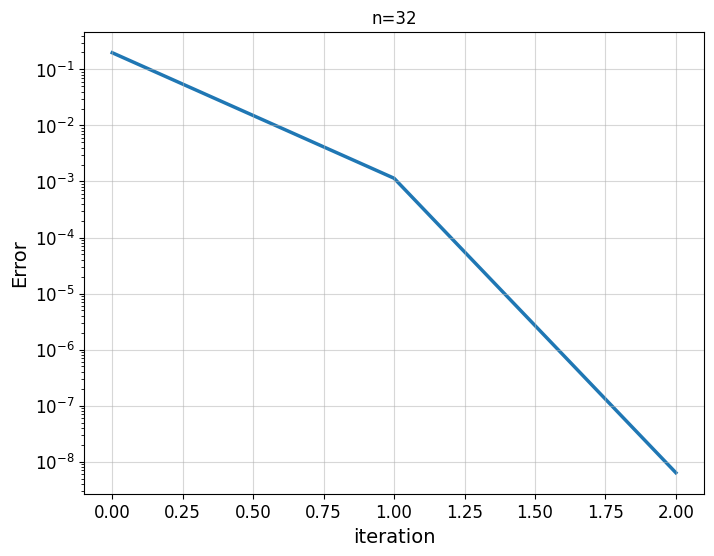

In [11]:
err=taktak.err
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)
steps = np.arange(0, len(err), dtype=int)
plt.plot(steps, err, lw=2.5, zorder=1)
plt.title(f"n={n}")
plt.xlabel('iteration', fontsize=14)
plt.ylabel('Error', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log')
plt.show()

Очевидно на 32 точках достигается сходимость на второй итерации..... 

Не знаю почему код так хорош, грешу на начальное приближение, оно линейное и здесь видимо